# Amazon E-commerce Sales Data Analysis

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

#### Loading Dataset

In [2]:
pd.set_option('display.max_columns',None)

df = pd.read_csv('Amazon Sale Report.csv',low_memory=False)

In [3]:
df.head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,B08B3XF5MH,Shipped,1,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


#### Inspection of Dataset

In [4]:
print(f"Dataset shape: {df.shape} rows x {len(df.columns)} columns")

Dataset shape: (128975, 24) rows x 24 columns


In [5]:
print(f"Datatypes: {df.dtypes}")

Datatypes: index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object


In [6]:
print(f"Inspecting Null Values: {df.isnull().sum().sort_values(ascending=False)}")

Inspecting Null Values: fulfilled-by          89698
promotion-ids         49153
Unnamed: 22           49050
currency               7795
Amount                 7795
Courier Status         6872
ship-country             33
ship-postal-code         33
ship-state               33
ship-city                33
ship-service-level        0
Style                     0
Date                      0
B2B                       0
Status                    0
Fulfilment                0
Sales Channel             0
Qty                       0
Order ID                  0
ASIN                      0
Size                      0
Category                  0
SKU                       0
index                     0
dtype: int64


In [7]:
print(f"Summary of Dataset: {df.describe()}")

Summary of Dataset:                index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  121180.000000     128942.000000
mean    64487.000000       0.904431     648.561465     463966.236509
std     37232.019822       0.313354     281.211687     191476.764941
min         0.000000       0.000000       0.000000     110001.000000
25%     32243.500000       1.000000     449.000000     382421.000000
50%     64487.000000       1.000000     605.000000     500033.000000
75%     96730.500000       1.000000     788.000000     600024.000000
max    128974.000000      15.000000    5584.000000     989898.000000


In [8]:
print(f"Total duplicated records: {df.duplicated().sum()}")

Total duplicated records: 0


#### Data cleaning

### 1. promotion - ids

In [9]:
df['promotion-ids'].sample(10)

51607                                                   NaN
23996                                                   NaN
121952         IN Core Free Shipping 2015/04/08 23-48-5-108
58464     Amazon PLCC Free-Financing Universal Merchant ...
76217                                                   NaN
73201     Amazon PLCC Free-Financing Universal Merchant ...
34197                Duplicated AYTJSBA8ZOP16 1567159860988
89665          IN Core Free Shipping 2015/04/08 23-48-5-108
121475    Amazon PLCC Free-Financing Universal Merchant ...
95982     Amazon PLCC Free-Financing Universal Merchant ...
Name: promotion-ids, dtype: object

In [10]:
df['Promotions'] = np.where(df['promotion-ids'].isna(),'No','Yes')

In [11]:
df.drop(columns=['promotion-ids'],inplace=True)

### 2. Unamed: 22

In [12]:
df['Unnamed: 22'].sample(10)

84788     False
60829     False
119463    False
2238        NaN
43737       NaN
112057    False
50345     False
74493     False
47860       NaN
63826     False
Name: Unnamed: 22, dtype: object

In [13]:
df['Unnamed: 22'].value_counts(dropna=False)

Unnamed: 22
False    79925
NaN      49050
Name: count, dtype: int64

In [14]:
df['Unnamed: 22'].nunique()

1

In [15]:
df.drop(columns=['Unnamed: 22'],inplace=True)

##### Unnamed: 22 column didnt gave any key insights and also had only one unique value 'False'.Hence, dropped the column

### 3. currency

In [16]:
df['currency'].sample(10)

23601    INR
55615    NaN
83674    INR
54993    INR
29003    INR
37957    INR
60332    NaN
34537    INR
96503    INR
37192    INR
Name: currency, dtype: object

In [17]:
df['currency'].isnull().sum()

np.int64(7795)

In [18]:
df['currency'].nunique()

1

In [19]:
df['currency'] = df['currency'].fillna(value='INR')

In [20]:
df['currency'].isnull().sum()

np.int64(0)

### 4. Amount

In [21]:
df['Amount'].sample(10)

15424      571.0
51117      518.0
33744      540.0
2274       519.0
9847       329.0
71030     1349.0
119957     345.0
40245      771.0
73661      560.0
13722        NaN
Name: Amount, dtype: float64

In [22]:
df['Amount'].isnull().sum()

np.int64(7795)

In [23]:
df = df[df['Amount'].notna()]

##### Rows with a missing Amount usually represent cancelled orders or orders that were never fulfilled.Hence, dropped the records that were empty

### 5. Courier Status

In [24]:
df['Courier Status'].sample(10)

57140     Unshipped
44353       Shipped
89276       Shipped
25325       Shipped
88452       Shipped
47567       Shipped
79229       Shipped
43931       Shipped
94272       Shipped
123106      Shipped
Name: Courier Status, dtype: object

In [25]:
df['Courier Status'].nunique()

2

In [26]:
df['Courier Status'].value_counts(dropna=False)

Courier Status
Shipped      109487
Unshipped      6557
NaN            5136
Name: count, dtype: int64

In [27]:
df['Courier Status'] = df['Courier Status'].fillna('Cancelled')

In [28]:
df['Courier Status'].isnull().sum()

np.int64(0)

In [29]:
df['Courier Status'].value_counts()

Courier Status
Shipped      109487
Unshipped      6557
Cancelled      5136
Name: count, dtype: int64

### 6. fulfilled-by

In [30]:
df['fulfilled-by'].sample(10)

86290           NaN
128781          NaN
114520          NaN
25183           NaN
7018            NaN
109130    Easy Ship
119559          NaN
122286          NaN
123470    Easy Ship
44704           NaN
Name: fulfilled-by, dtype: object

In [31]:
df['fulfilled-by'].isnull().sum()

np.int64(83639)

In [32]:
df['fulfilled-by'].nunique(dropna=False)

2

In [33]:
df['fulfilled-by'].value_counts(dropna=False)

fulfilled-by
NaN          83639
Easy Ship    37541
Name: count, dtype: int64

In [34]:
df['fulfilled-by'] = df['fulfilled-by'].fillna('Unknown')

In [35]:
df['fulfilled-by'].value_counts(dropna=False)

fulfilled-by
Unknown      83639
Easy Ship    37541
Name: count, dtype: int64

### 7. Dropping Null values from column : 'ship-city','ship-state', 'ship-postal-code', 'ship-country'

In [36]:
df.isnull().sum()

index                  0
Order ID               0
Date                   0
Status                 0
Fulfilment             0
Sales Channel          0
ship-service-level     0
Style                  0
SKU                    0
Category               0
Size                   0
ASIN                   0
Courier Status         0
Qty                    0
currency               0
Amount                 0
ship-city             31
ship-state            31
ship-postal-code      31
ship-country          31
B2B                    0
fulfilled-by           0
Promotions             0
dtype: int64

In [37]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by',
       'Promotions'],
      dtype='object')

##### Dropped 'ship-city','ship-state', 'ship-postal-code', 'ship-country' as there were less amount records which were null

In [38]:
df = df.dropna(subset=['ship-city','ship-state', 'ship-postal-code', 'ship-country'])

##### Checking the dataset for further cleaning:-

In [39]:
df.isnull().sum()

index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
fulfilled-by          0
Promotions            0
dtype: int64

In [40]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,121149.000000,121149.000000,121149.000000,121149.000000
mean,64483.736259,0.961246,648.573305,463652.687525
std,37221.261564,0.214327,281.222115,191316.128616
min,0.000000,0.000000,0.000000,110001.000000
25%,32290.000000,1.000000,449.000000,382421.000000
50%,64474.000000,1.000000,605.000000,500032.000000
75%,96681.000000,1.000000,788.000000,600021.000000
max,128974.000000,8.000000,5584.000000,989898.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121149 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               121149 non-null  int64  
 1   Order ID            121149 non-null  object 
 2   Date                121149 non-null  object 
 3   Status              121149 non-null  object 
 4   Fulfilment          121149 non-null  object 
 5   Sales Channel       121149 non-null  object 
 6   ship-service-level  121149 non-null  object 
 7   Style               121149 non-null  object 
 8   SKU                 121149 non-null  object 
 9   Category            121149 non-null  object 
 10  Size                121149 non-null  object 
 11  ASIN                121149 non-null  object 
 12  Courier Status      121149 non-null  object 
 13  Qty                 121149 non-null  int64  
 14  currency            121149 non-null  object 
 15  Amount              121149 non-null  fl

### 8. changing date datatype:-

In [42]:
df['Date'].dtype

dtype('O')

In [43]:
df['Date'] = pd.to_datetime(df['Date'],format='%m-%d-%y',errors='coerce')

In [44]:
df['Date'].dtype

dtype('<M8[ns]')

#### 9. Creating Day, Month, Year variables

In [45]:
df['Day'] = df['Date'].dt.day_name()

In [46]:
df['Day'].sample(5)

101859       Monday
84980     Wednesday
74967       Tuesday
107172    Wednesday
68774        Sunday
Name: Day, dtype: object

In [47]:
df['Month'] = df['Date'].dt.month_name()

In [48]:
df['Month'].sample(5)

54652      May
60320      May
20594    April
64631      May
83825      May
Name: Month, dtype: object

In [49]:
df['Year'] = df['Date'].dt.year

In [50]:
df['Year'].sample(5)

60591    2022
10430    2022
79118    2022
19141    2022
35752    2022
Name: Year, dtype: int32

In [51]:
df['Year'].value_counts()

Year
2022    121149
Name: count, dtype: int64

##### 10. Removing white spaces from Category column:

In [52]:
df['Category'] = df['Category'].str.strip()

In [53]:
df['Category'].sample(10)

36097    Western Dress
77826              Top
49634              Set
76840    Western Dress
95795            kurta
97034    Western Dress
40458    Western Dress
52453              Top
57072              Set
29923              Set
Name: Category, dtype: object

#### 11. Converting 'ship-postal-code' float to Int datatype:-

In [54]:
df['ship-postal-code'].sample(5)

9547      517583.0
29412     560072.0
97305     248001.0
73410     201301.0
108828    380051.0
Name: ship-postal-code, dtype: float64

In [55]:
df['ship-postal-code'] = df['ship-postal-code'].astype(int)

In [56]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,Promotions,Day,Month,Year
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Cancelled,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,False,Easy Ship,No,Saturday,April,2022
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085,IN,False,Easy Ship,Yes,Saturday,April,2022
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,True,Unknown,Yes,Saturday,April,2022
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Cancelled,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False,Easy Ship,No,Saturday,April,2022
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,False,Unknown,No,Saturday,April,2022


## Data Cleaning Summary:-
1. Created a new column Promotions from promotion-ids indicating binary Yes/No values for specific products or Category promotions
2. Dropped Unnamed: 22 column as it contained mostly Null values and provided no useful analytical insights for the dataset
3. Filled Null values in currency column with 'INR' because Indian Rupees was the only unique currency present in the data
4. Dropped records with missing values in Amount column to avoid data discrepancy, as empty amounts represent unfulfilled or cancelled orders
5. Filled Null values in Courier Status column with 'Cancelled' based on the existing unique categories (Shipped, Unshipped, and NaN)
6. Filled Null values in fulfilled-by column with 'Unknown' to resolve blank entries since the only valid option was Easy Ship
7. Dropped Null values from address columns (ship-city, ship-state, ship-postal-code, ship-country) because the volume of missing data was very low
8. Converted data type of Date column from string object to proper DateTime format
9. Created new explicit columns for Day, Month, and Year by extracting dimensions directly from the cleaned Date column
10. Removed unnecessary leading and trailing white spaces from string values within the Category column
11. Changed data type of ship-postal-code column from float to int to remove the trailing decimal formatting

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121149 entries, 0 to 128974
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               121149 non-null  int64         
 1   Order ID            121149 non-null  object        
 2   Date                121149 non-null  datetime64[ns]
 3   Status              121149 non-null  object        
 4   Fulfilment          121149 non-null  object        
 5   Sales Channel       121149 non-null  object        
 6   ship-service-level  121149 non-null  object        
 7   Style               121149 non-null  object        
 8   SKU                 121149 non-null  object        
 9   Category            121149 non-null  object        
 10  Size                121149 non-null  object        
 11  ASIN                121149 non-null  object        
 12  Courier Status      121149 non-null  object        
 13  Qty                 121149 non-nul

## Exploratory Data Analysis (EDA):-

### Business Objectives:-

1. Sales Performance Tracking:-

   Question: Which product categories generate the highest total revenue, and when are customers buying them?

   Approach: Identify our top-selling items and trace buying patterns across different months and years.

   Question: What does our overall sales growth trajectory look like over time?

   Approach: Track the continuous rise and fall of total sales revenue from the start to the end of the timeline.

2. Promotion Effectiveness:-

   Question: Do promotional campaigns actually drive higher sales volumes and larger customer cart sizes?
   
   Approach: Compare the average amount spent by customers on discounted orders versus non-discounted orders.
   
   Question: Which specific product categories respond best to promotions?
   
   Approach: Pinpoint which item types see the biggest jump in popularity when a deal is active.

3. Operational & Logistics Efficiency:-

   Question: What percentage of our total orders are failing to reach customers, and where are the operational bottlenecks?

   Approach: Measure the total share of failed deliveries to find out where orders are getting stuck.

   Question: How does Amazon's fulfillment performance compare to merchant fulfillment?

   Approach: Check whether platform-managed shipping results in fewer order cancellations than self-shipping.

4. Geographic Market Demand:-

   Question: Which regions, states, and cities represent our highest-value e-commerce markets?

   Approach: Rank our geographical locations from highest to lowest based on total money spent by customers.

   Question: How should inventory be distributed across pin codes to optimise shipping times?

   Approach: Find the specific postal areas with the heaviest order volumes to help stock local warehouses.

## Expected Outcomes & Insights:-

Revenue Optimization: Identify top-selling items and peak buying times to maximize sales during high-demand periods.

Profitable Promotion Strategy: Pinpoint which products benefit most from discounts to design higher-margin promotional campaigns.

Minimized Operational Losses: Expose delivery bottlenecks and cancellation trends to choose the most efficient shipping methods.

Data-Driven Inventory Deployment: Map out high-volume regions and postal codes to stock warehouses closer to major customer hubs.

### Sales Performance Tracking:-

Business Question 1. Which product categories generate the highest total revenue, and when are customers buying them?

Business Question 2. What does our overall sales growth trajectory look like over time?

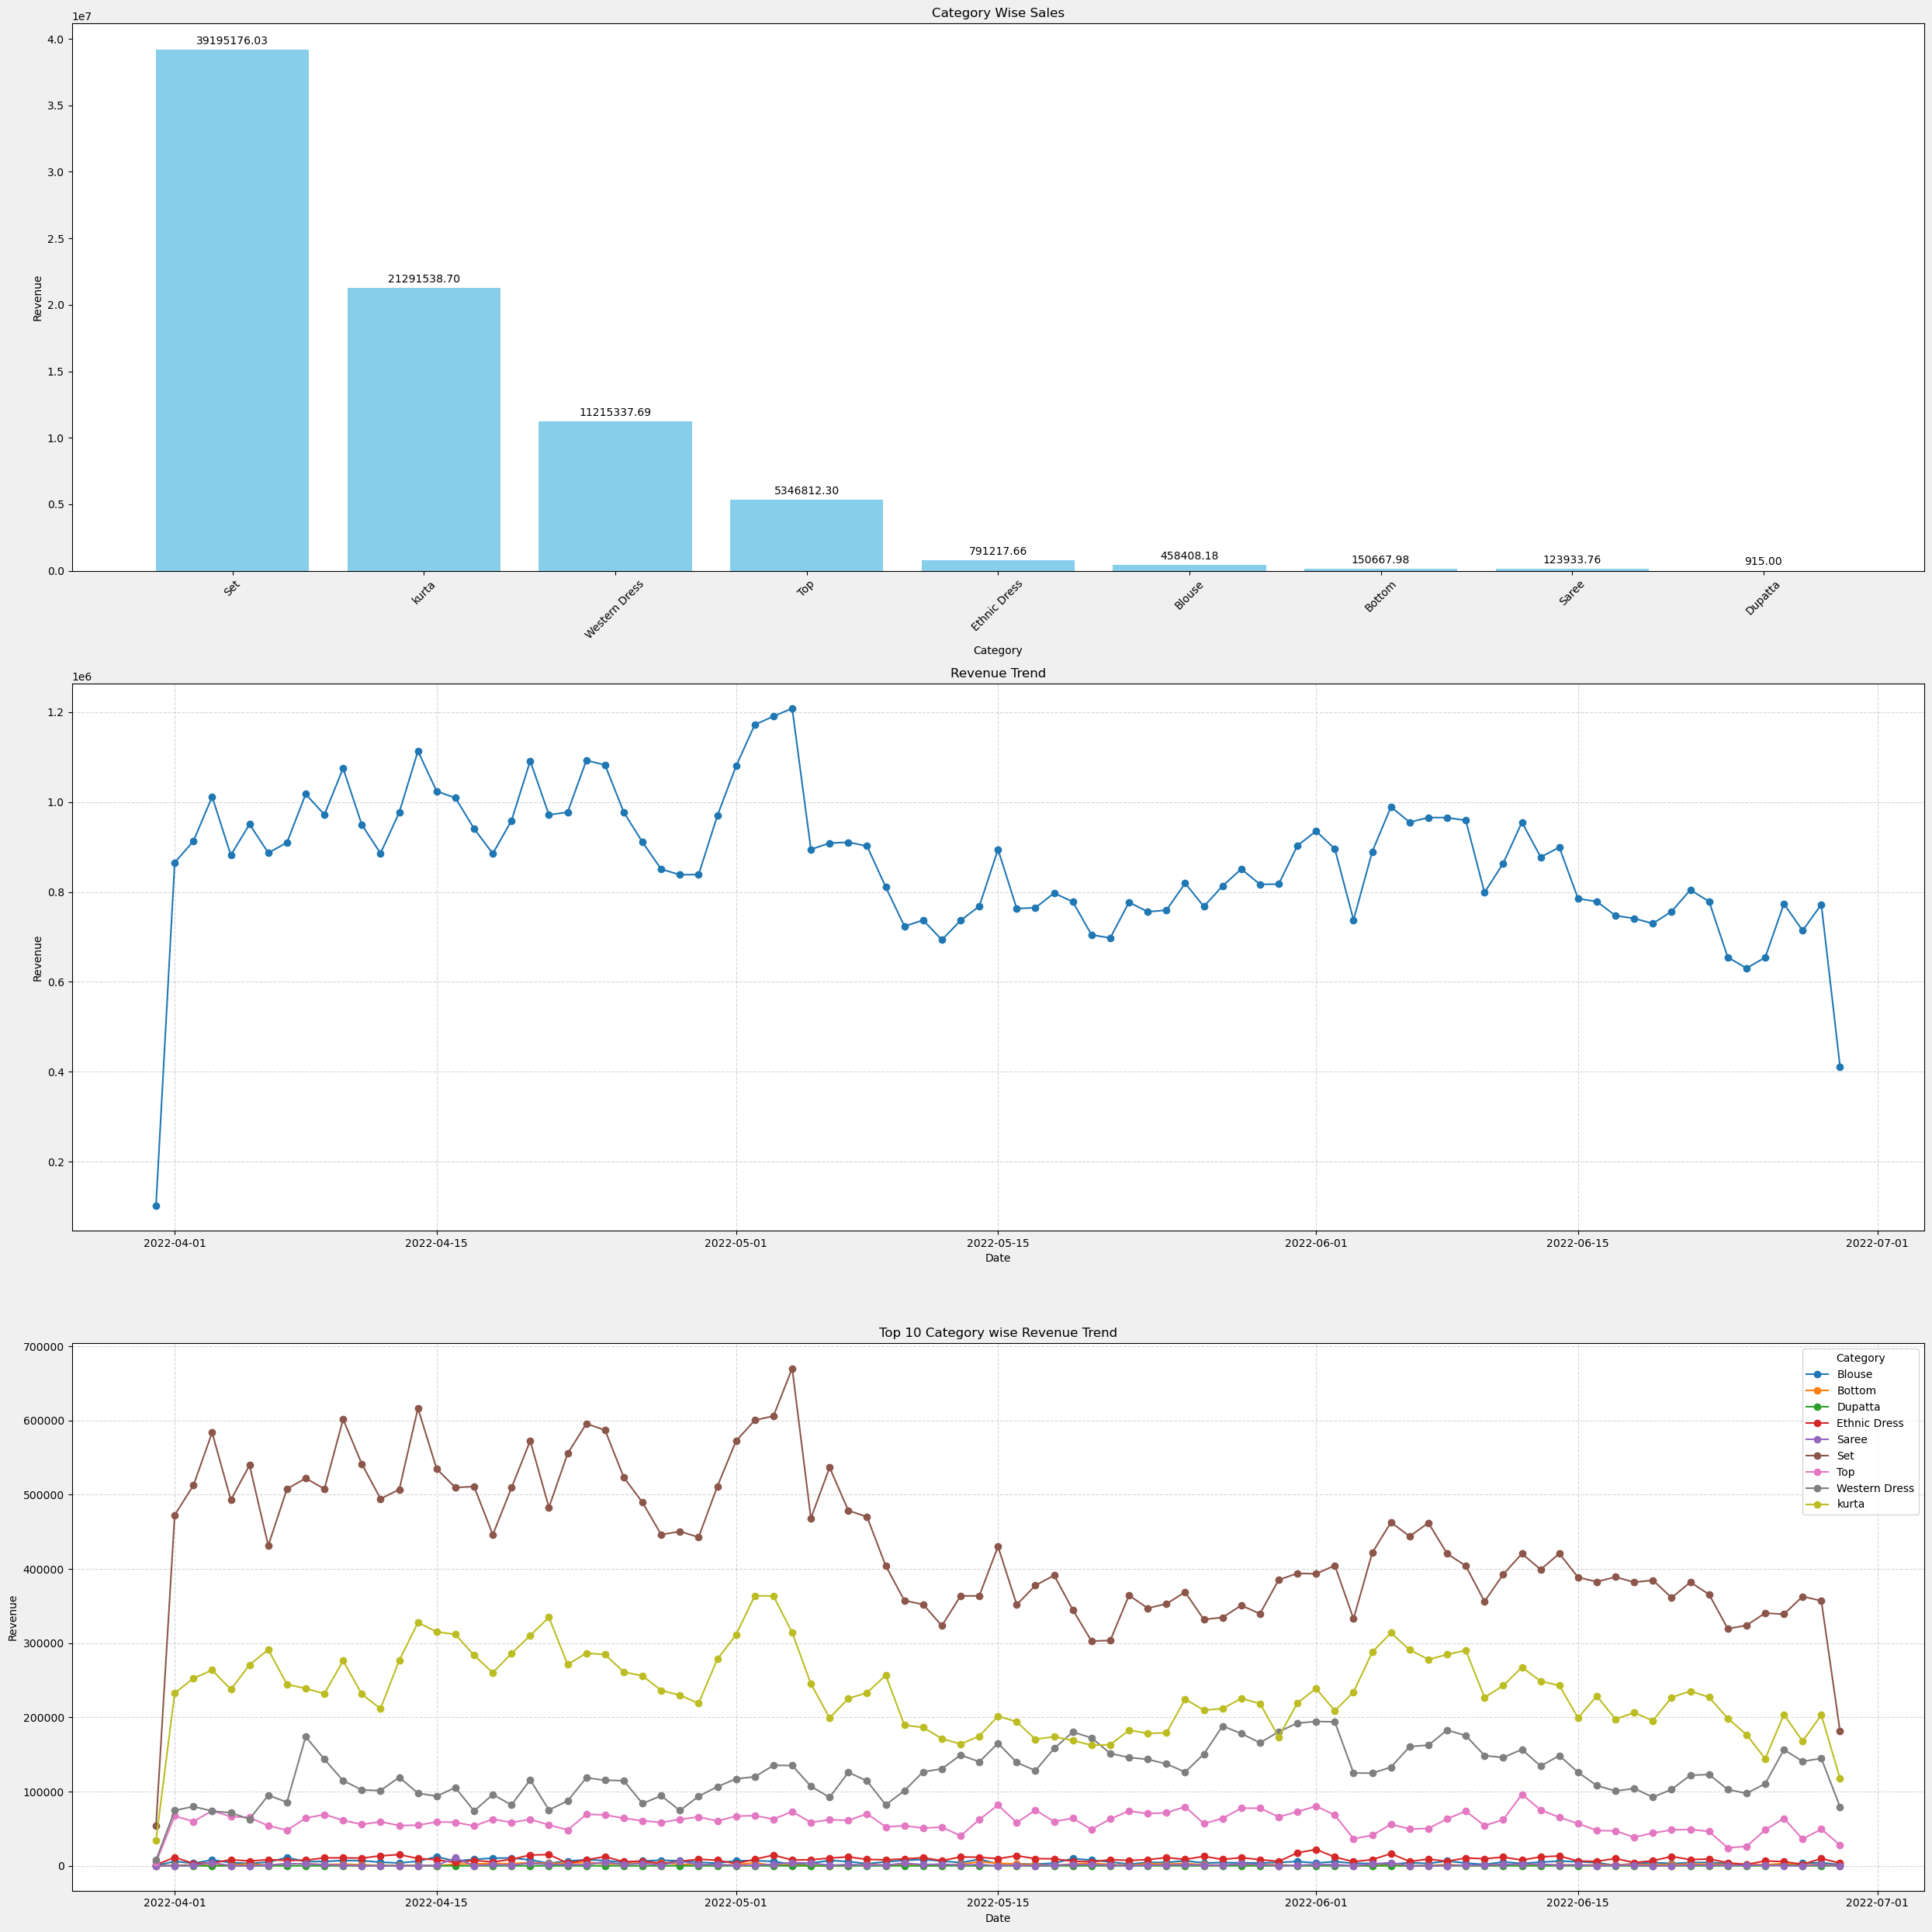

In [107]:

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(25,25),facecolor='#f0f0f0')

df_bar = df.groupby('Category',as_index=False)['Amount'].sum()
df_bar_sorted = df_bar.sort_values(by='Amount',ascending=False).head(10) # Only Top 10 category

df_line = df.groupby('Date',as_index=False)['Amount'].sum()
df_line_sorted = df_line.sort_values(by='Date') # making sure that dates are chronological

ax[0].bar(df_bar_sorted['Category'],df_bar_sorted['Amount'],color = 'skyblue')
ax[0].set(title = 'Category Wise Sales',xlabel = 'Category',ylabel='Revenue')
ax[0].tick_params(axis='x',rotation = 45)
ax[0].bar_label(ax[0].containers[0],padding=3,fmt = '%.2f')

ax[1].plot(df_line_sorted['Date'],df_line_sorted['Amount'],color = 'tab:blue',marker='o')
ax[1].set(title = 'Revenue Trend',xlabel='Date',ylabel='Revenue')
ax[1].grid(True,linestyle='--',alpha=0.5)

top_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10).index.tolist()
monthly_category = df[df['Category'].isin(top_category)].groupby(['Date','Category'])['Amount'].sum().unstack(fill_value=0).round(0)
monthly_category.index = pd.to_datetime(monthly_category.index)

for category in monthly_category.columns:
    ax[2].plot(monthly_category.index,monthly_category[category],marker='o',label=category)

ax[2].set(title = 'Top 10 Category wise Revenue Trend',xlabel = 'Date',ylabel='Revenue')
ax[2].grid(True,linestyle='--',alpha = 0.5)
ax[2].legend(title='Category')

plt.tight_layout()
plt.show()

##### Conclsuion: 
1. The Set category is our primary revenue driver, generating the highest total sales, followed by the Kurta category as the second-highest performer.
2. Revenue Trend (Q2 2022): Revenue experienced a sharp upward trajectory at the beginning of April, followed by a period of stabilization (sideways movement). Sales peaked at their highest value in May before entering a steady downward trend through the end of June 2022.
3. Also in Category wise Trend graph, From April through mid-May 2022, the Set category consistently led revenue generation, firmly established as the market frontrunner, closely followed by the Kurta category.
4. Q2 2022 sales experienced a sharp early-April surge, hitting an all-time high in early May before entering a gradual, steady decline through the end of June.

### Promotion Effectiveness:-

Business Question 1: Do promotional campaigns actually drive higher sales volumes and larger customer cart sizes?


Business Question 2: Which specific product categories respond best to promotions?


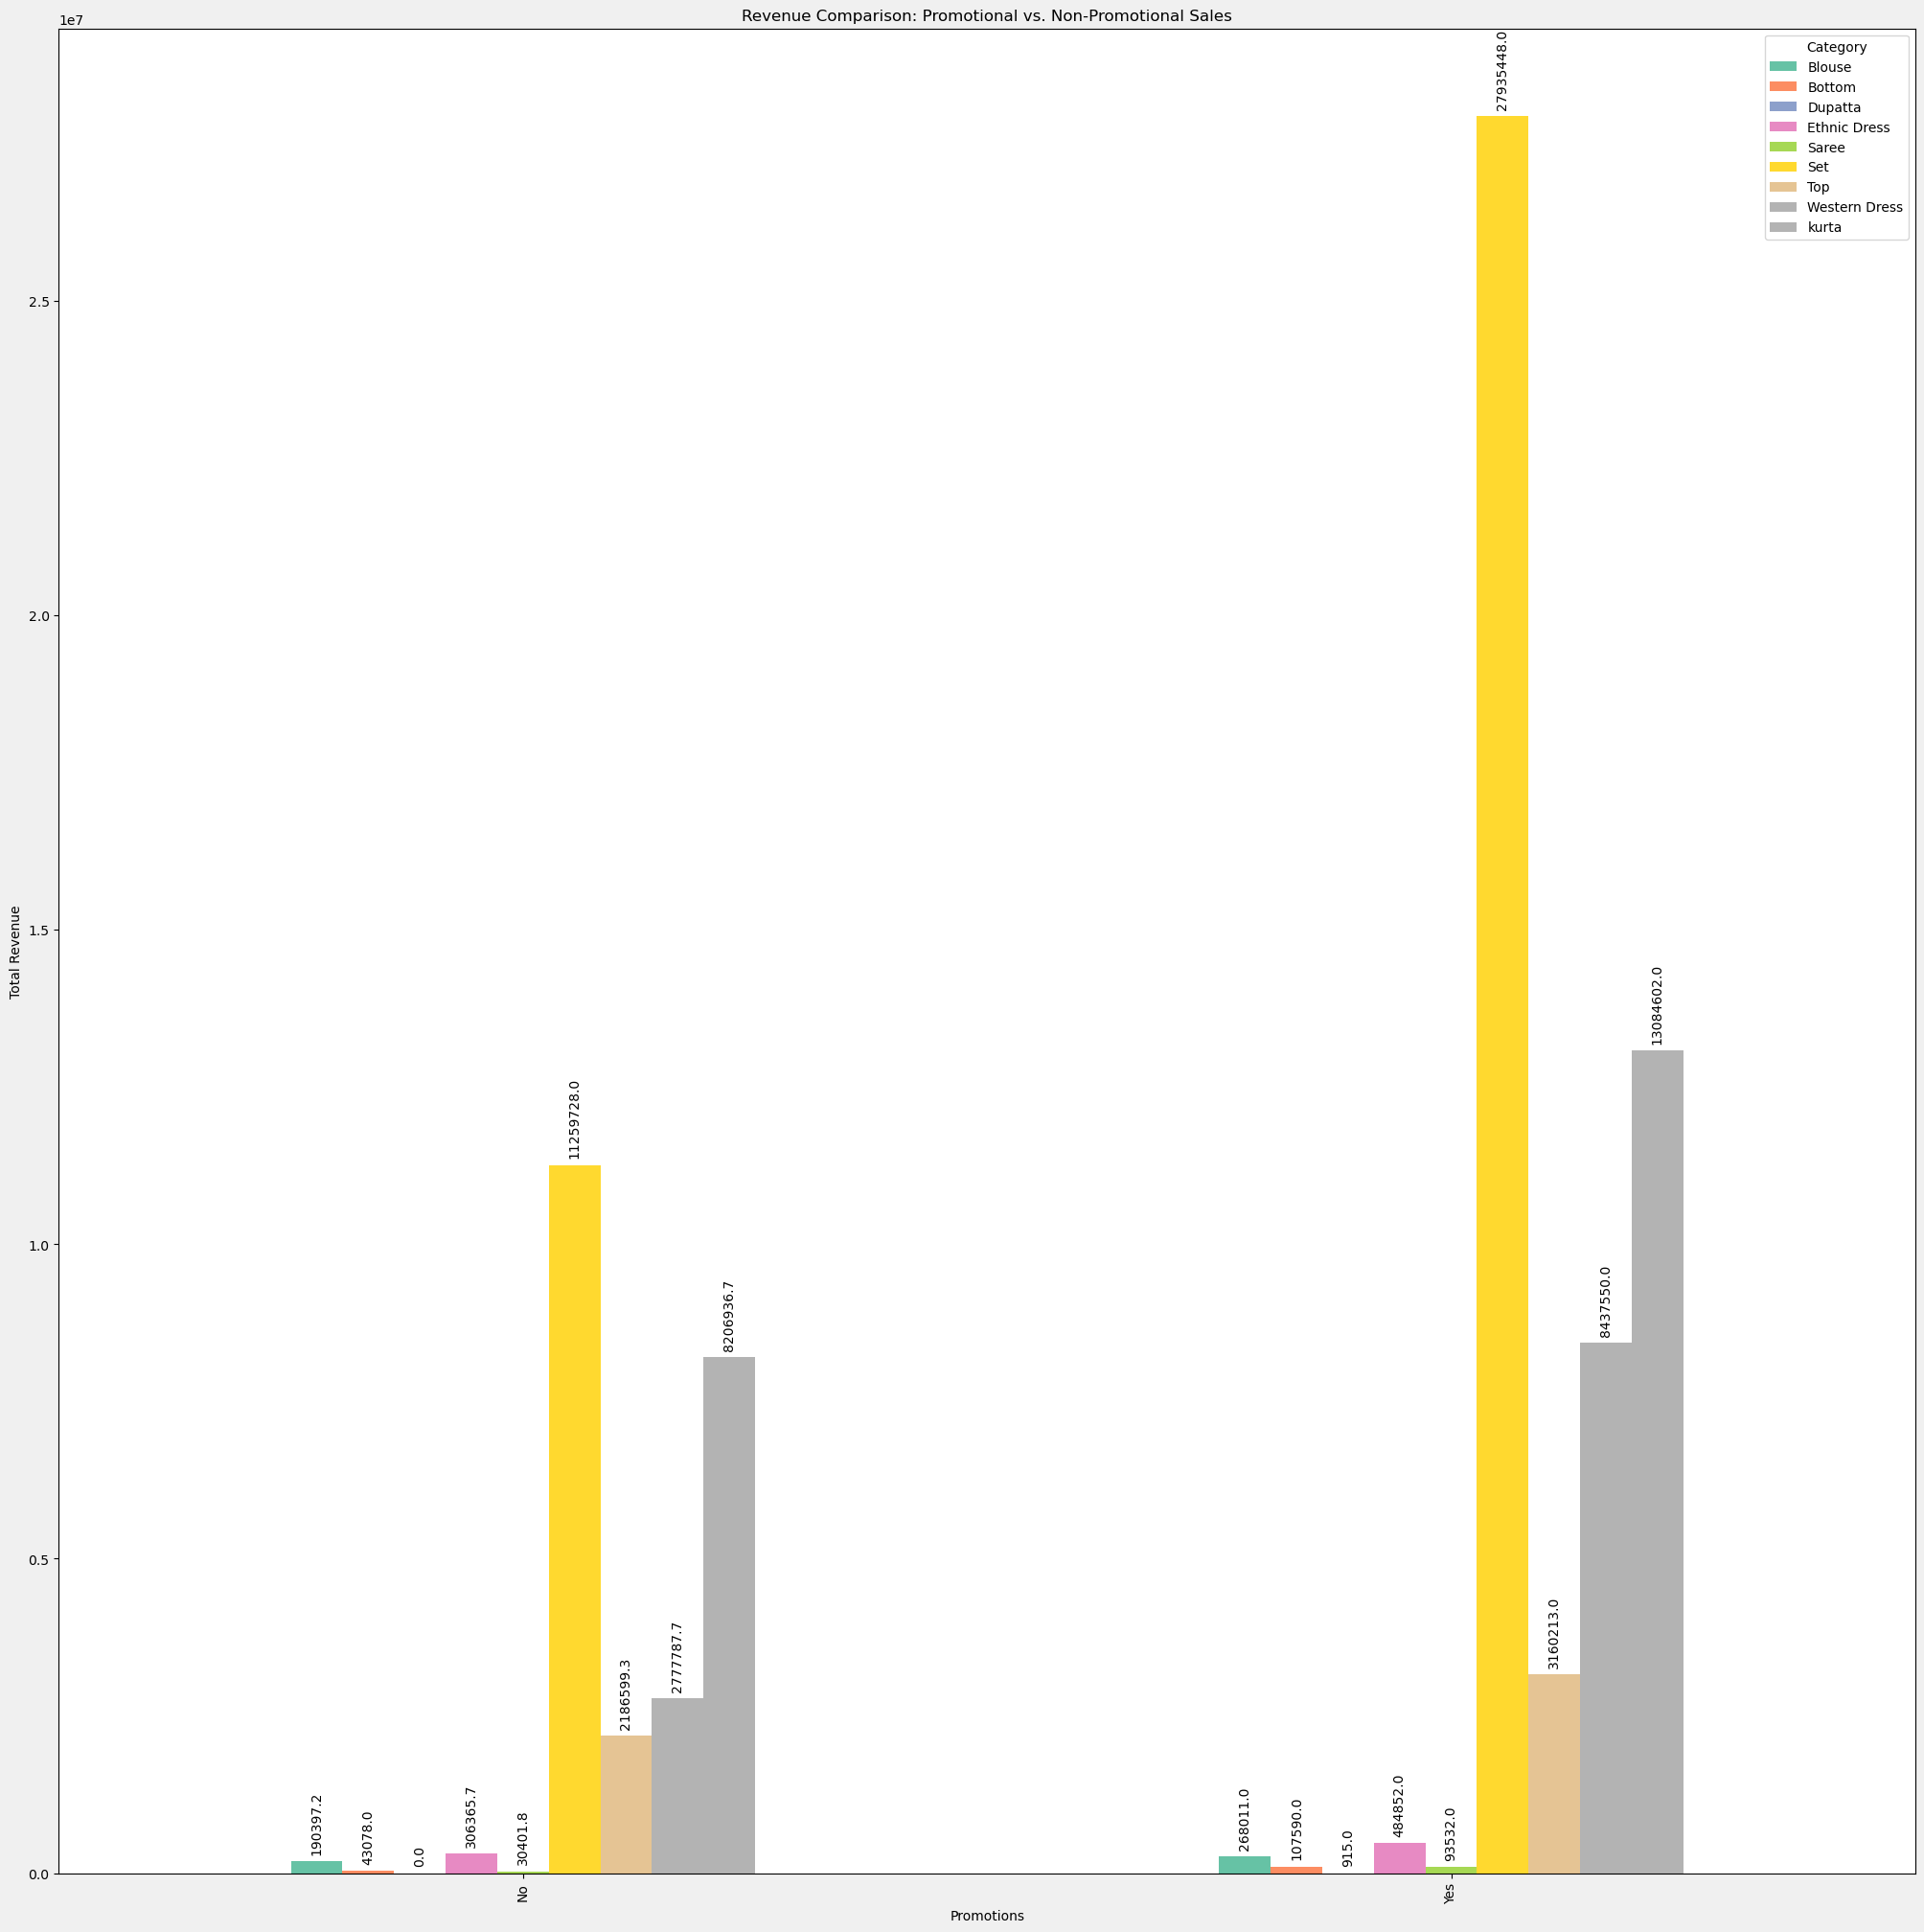

In [60]:
fig, ax = plt.subplots(figsize = (25,25),facecolor='#f0f0f0')

df_bar1 = df.groupby(['Promotions','Category'])['Amount'].sum().unstack(fill_value=0)
df_bar1.plot(kind='bar',ax=ax,cmap='Set2')
ax.set(title='Revenue Comparison: Promotional vs. Non-Promotional Sales',xlabel='Promotions',ylabel='Total Revenue')

for container in ax.containers:
    ax.bar_label(container,padding=5,fmt='%.1f',rotation=90,label_type='edge')

#ax.bar_label(ax.containers,padding=3,fmt='%.2f')
ax.legend(title='Category')

plt.show()

##### Conclusion:-
1. Universal Sales Lift: Promotions triggered exponential growth in high-volume segments and unlocked vital revenue in lower-performing categories.
2. Top Revenue Drivers: Sets generated the highest total turnover, closely followed by Kurtas as the second-largest revenue contributor.
3. Mid-Growth Segments: Western Dresses and Tops delivered optimal revenue surges directly tied to promotional windows.

### Operational & Logistics Efficiency:-

  Business Question 1: What percentage of our total orders are failing to reach customers, and where are the operational bottlenecks?

  Business Question 2: How does Amazon's fulfillment performance compare to merchant fulfillment?


In [61]:
(df['Courier Status'].value_counts(normalize=True)*100).map('{:.2f}%'.format)

Courier Status
Shipped      90.35%
Unshipped     5.41%
Cancelled     4.24%
Name: proportion, dtype: object

In [62]:
(df['Status'].value_counts(normalize=True)*100).map('{:.2f}%'.format)

Status
Shipped                          64.04%
Shipped - Delivered to Buyer     23.73%
Cancelled                         8.88%
Shipped - Returned to Seller      1.61%
Shipped - Picked Up               0.80%
Pending                           0.54%
Pending - Waiting for Pick Up     0.23%
Shipped - Returning to Seller     0.12%
Shipped - Out for Delivery        0.03%
Shipped - Rejected by Buyer       0.01%
Shipped - Lost in Transit         0.00%
Shipped - Damaged                 0.00%
Name: proportion, dtype: object

In [63]:
# % of order cancelled out of total orders

(df[~df['Status'].isin(['Shipped','Shipped - Delivered to Buyer'])]['Status'].value_counts(normalize=True)*100).map('{:.2f}%'.format)

Status
Cancelled                        72.64%
Shipped - Returned to Seller     13.14%
Shipped - Picked Up               6.57%
Pending                           4.43%
Pending - Waiting for Pick Up     1.90%
Shipped - Returning to Seller     0.98%
Shipped - Out for Delivery        0.24%
Shipped - Rejected by Buyer       0.07%
Shipped - Lost in Transit         0.03%
Shipped - Damaged                 0.01%
Name: proportion, dtype: object

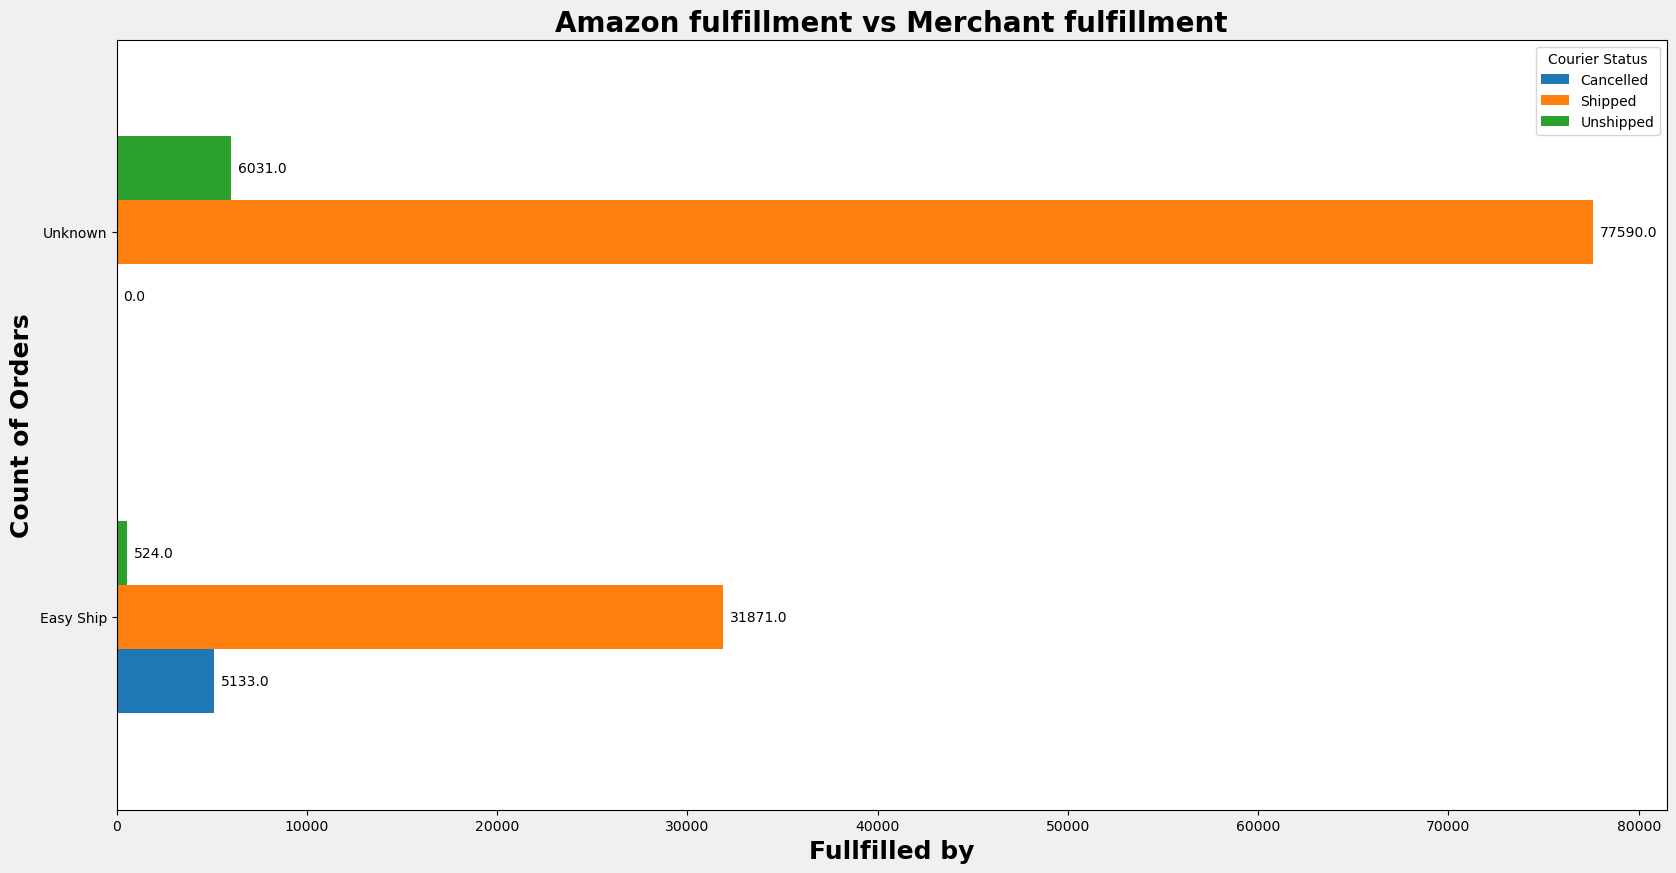

In [104]:
fulfilled_inspection = df.groupby(['fulfilled-by','Courier Status'])['index'].count().sort_values(ascending=False).unstack(fill_value=0)

fig, ax = plt.subplots(facecolor='#f0f0f0') # To Set the outer background color when creating the figure
fulfilled_inspection.plot(kind='barh',ax=ax,figsize=(20,10)) # facecolor='grey' to change the inner background
ax.set_title('Amazon fulfillment vs Merchant fulfillment',fontsize=20,fontweight='bold')
ax.set_xlabel('Fullfilled by',fontsize=18,fontweight='bold')
ax.set_ylabel('Count of Orders',fontsize=18,fontweight='bold')


for container in ax.containers:
    ax.bar_label(container,padding=5,fmt='%.1f',label_type='edge')

##### Conclusion:-
Overall Operational Impact: When looking at the entire dataset, cancellations are low, accounting for only 8.88% of total orders. This indicates that the vast majority of orders move successfully through the fulfillment pipeline.

Non-Delivered Segment Risk: When excluding shipped orders, cancellations spike drastically to 72.64% of the remaining backlog. This proves that cancellation is the primary reason an order fails to ship, rather than logistical delays or missing inventory.

Merchant Fulfillment: Achieved higher overall delivery volumes with a 0% cancellation rate, but faces severe processing bottlenecks leading to a high backlog of unshipped orders.

Amazon Easy Ship: Maintains an exceptionally clean pipeline with near-zero unshipped orders, but suffers from lower final delivery counts and a high cancellation rate.

### Geographic Market Demand:-

Business Question 1: Which regions, states, and cities represent our highest-value e-commerce markets?

Business Question 2: How should inventory be distributed across pin codes to optimise shipping times?


In [69]:
df['ship-state'] = df['ship-state'].str.upper()

In [70]:
df['ship-state'].value_counts()

ship-state
MAHARASHTRA               21073
KARNATAKA                 16394
TAMIL NADU                10809
TELANGANA                 10637
UTTAR PRADESH              9947
DELHI                      6569
KERALA                     6151
WEST BENGAL                5547
ANDHRA PRADESH             5055
HARYANA                    4188
GUJARAT                    4153
RAJASTHAN                  2529
MADHYA PRADESH             2367
ODISHA                     1995
BIHAR                      1963
PUNJAB                     1803
ASSAM                      1548
UTTARAKHAND                1445
JHARKHAND                  1352
GOA                        1081
CHHATTISGARH                864
HIMACHAL PRADESH            724
JAMMU & KASHMIR             649
PUDUCHERRY                  326
CHANDIGARH                  318
MANIPUR                     301
ANDAMAN & NICOBAR           243
MEGHALAYA                   197
SIKKIM                      190
NAGALAND                    180
TRIPURA                     1

In [73]:
df['ship-city'] = df['ship-city'].str.upper()

In [77]:
df['ship-city'].value_counts()

ship-city
BENGALURU                   11324
HYDERABAD                    8591
MUMBAI                       6809
NEW DELHI                    5975
CHENNAI                      5959
                            ...  
THIRUMALAIRAYAN PATTINAM        1
MANNANCHERY                     1
DUDAHI, KUSHINAGAR              1
MANDYA DISTIC                   1
PRAYAGRAJ (ALLAHABAD)           1
Name: count, Length: 7099, dtype: int64

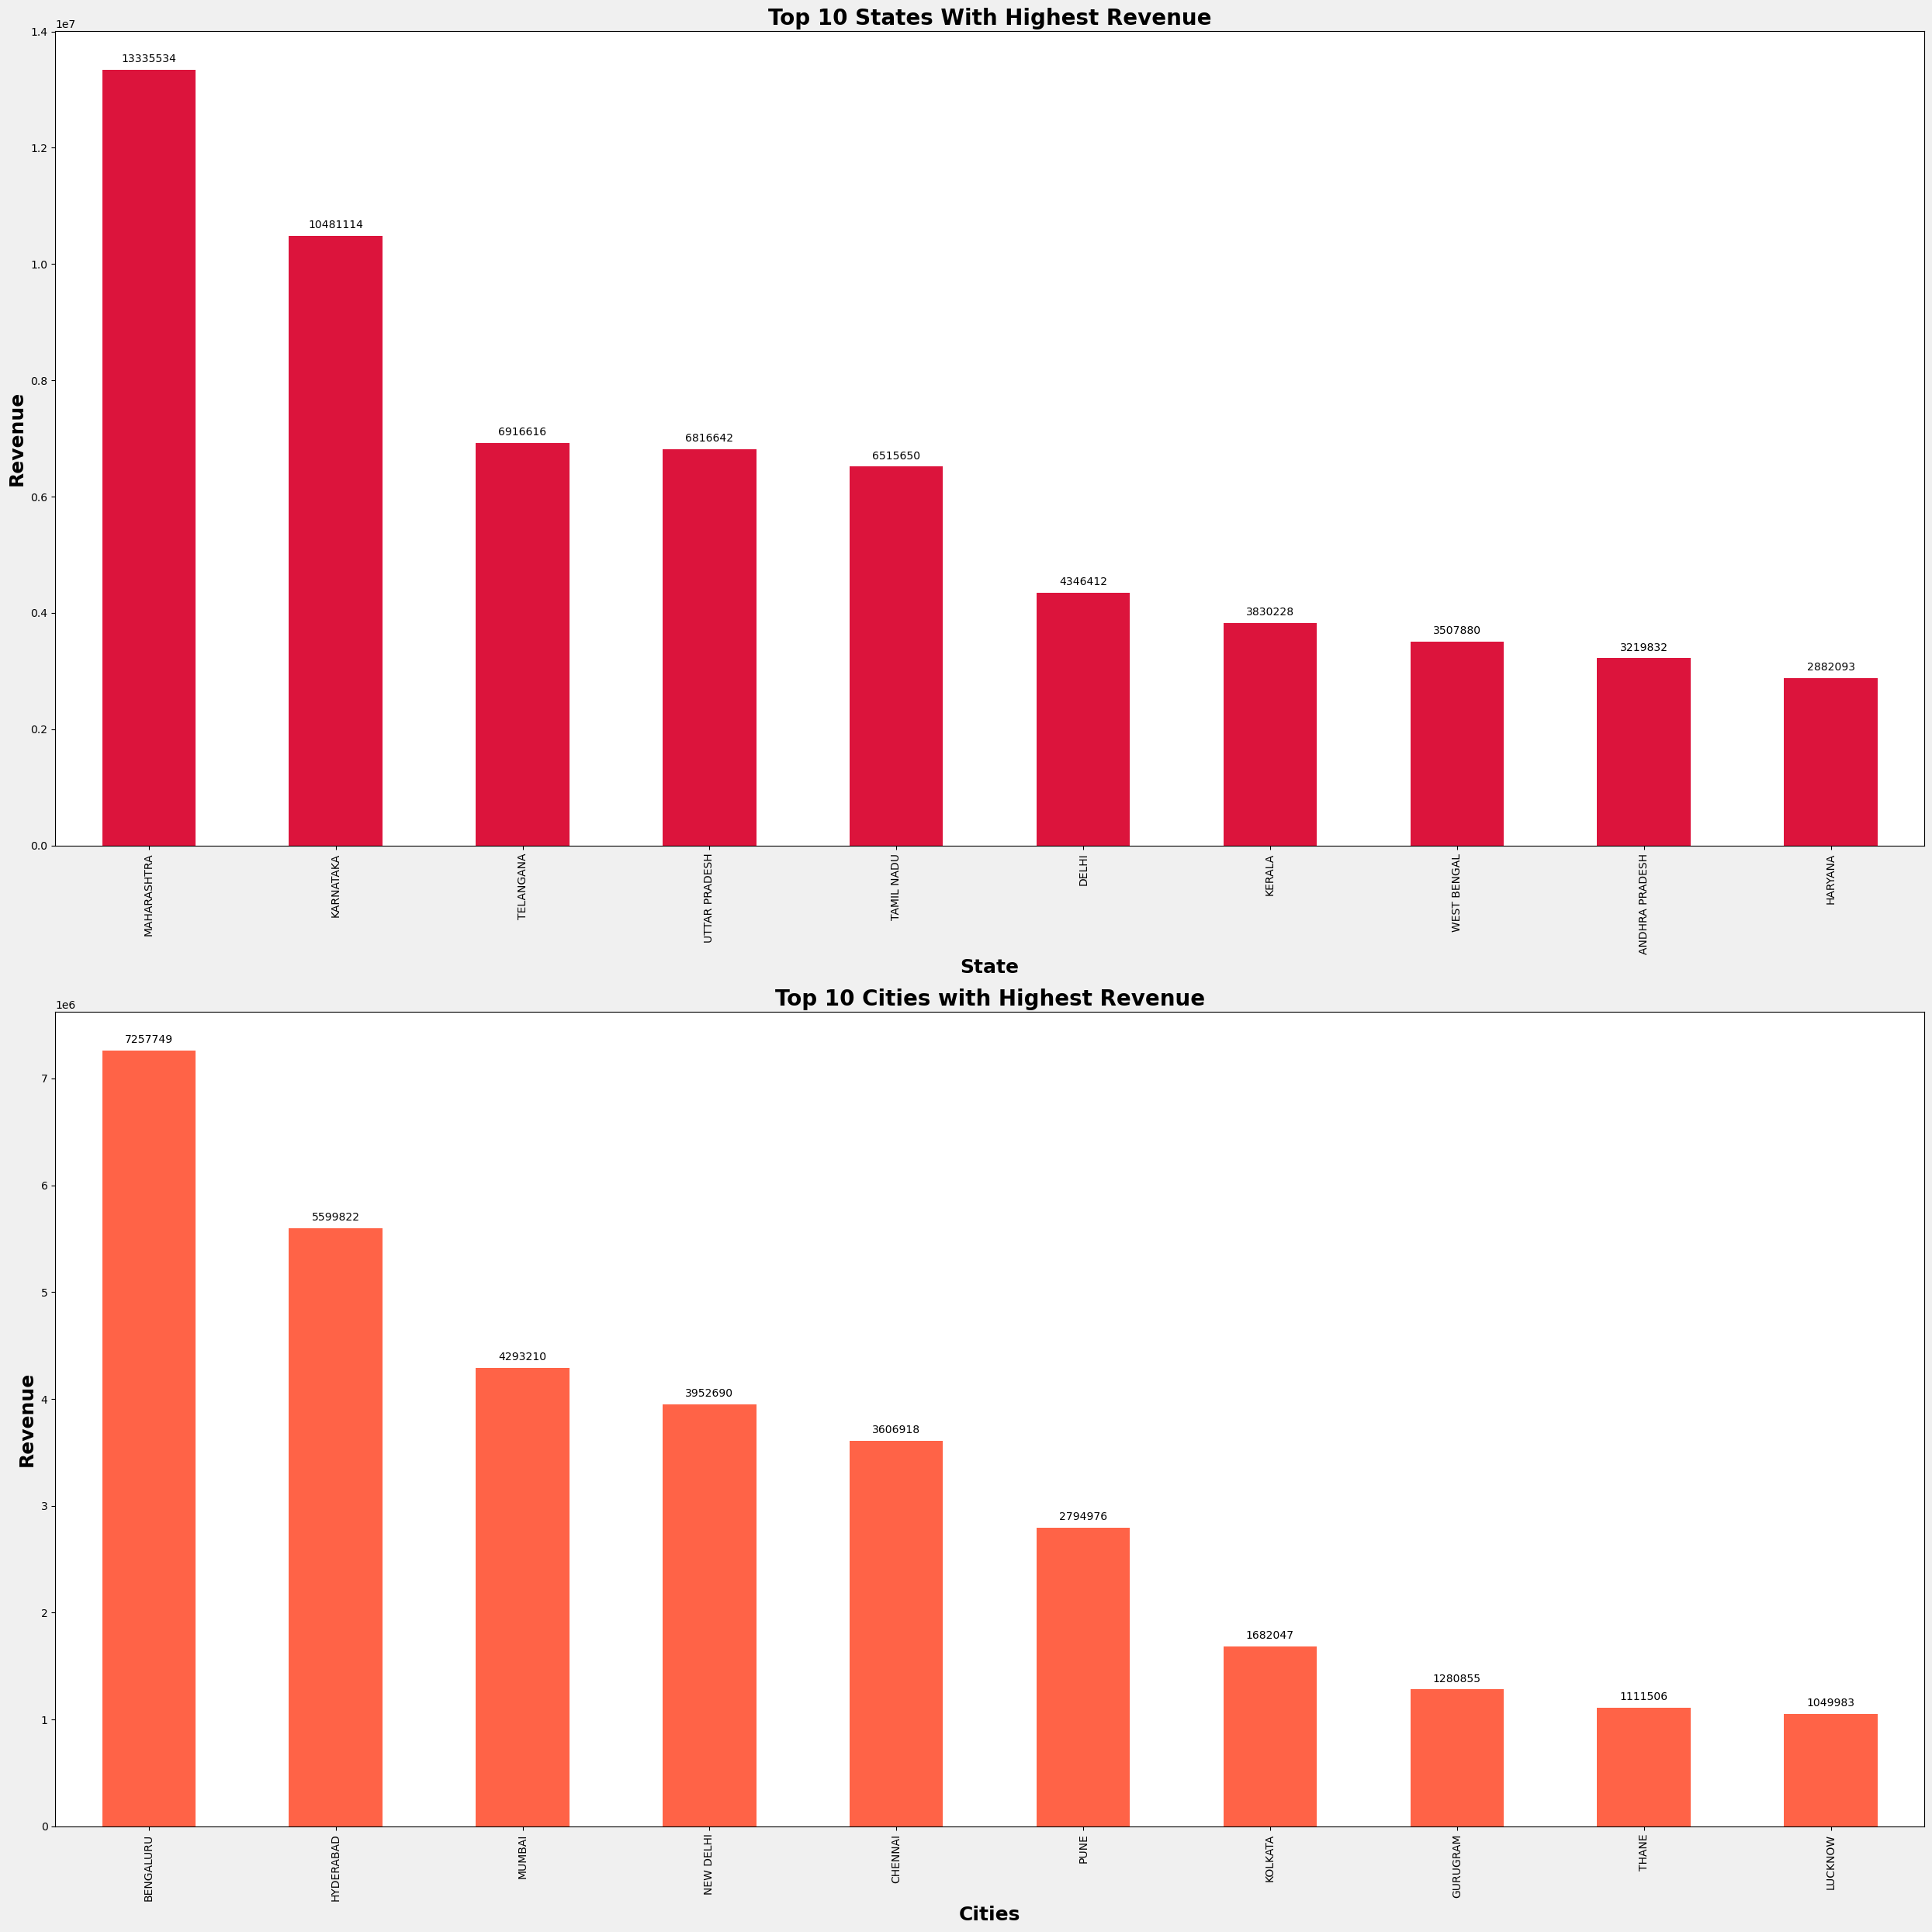

In [105]:
df_state_revenue = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
df_city_revenue = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(25,25),facecolor='#f0f0f0')
df_state_revenue.plot(kind='bar',ax=ax[0],color='crimson')
ax[0].set_title('Top 10 States With Highest Revenue',fontsize=20,fontweight='bold')
ax[0].set_xlabel('State',fontsize=18,fontweight='bold')
ax[0].set_ylabel('Revenue',fontsize=18,fontweight='bold')

for container in ax[0].containers:
    ax[0].bar_label(container,padding=5,fmt='%.f',label_type='edge')

df_city_revenue.plot(kind='bar',ax=ax[1],color='tomato')
ax[1].set_title('Top 10 Cities with Highest Revenue',fontsize=20,fontweight='bold')
ax[1].set_xlabel('Cities',fontsize=18,fontweight='bold')
ax[1].set_ylabel('Revenue',fontsize=18,fontweight='bold')

for container in ax[1].containers:
    ax[1].bar_label(container,padding=5,fmt='%.f',label_type='edge')

plt.tight_layout()
plt.show()

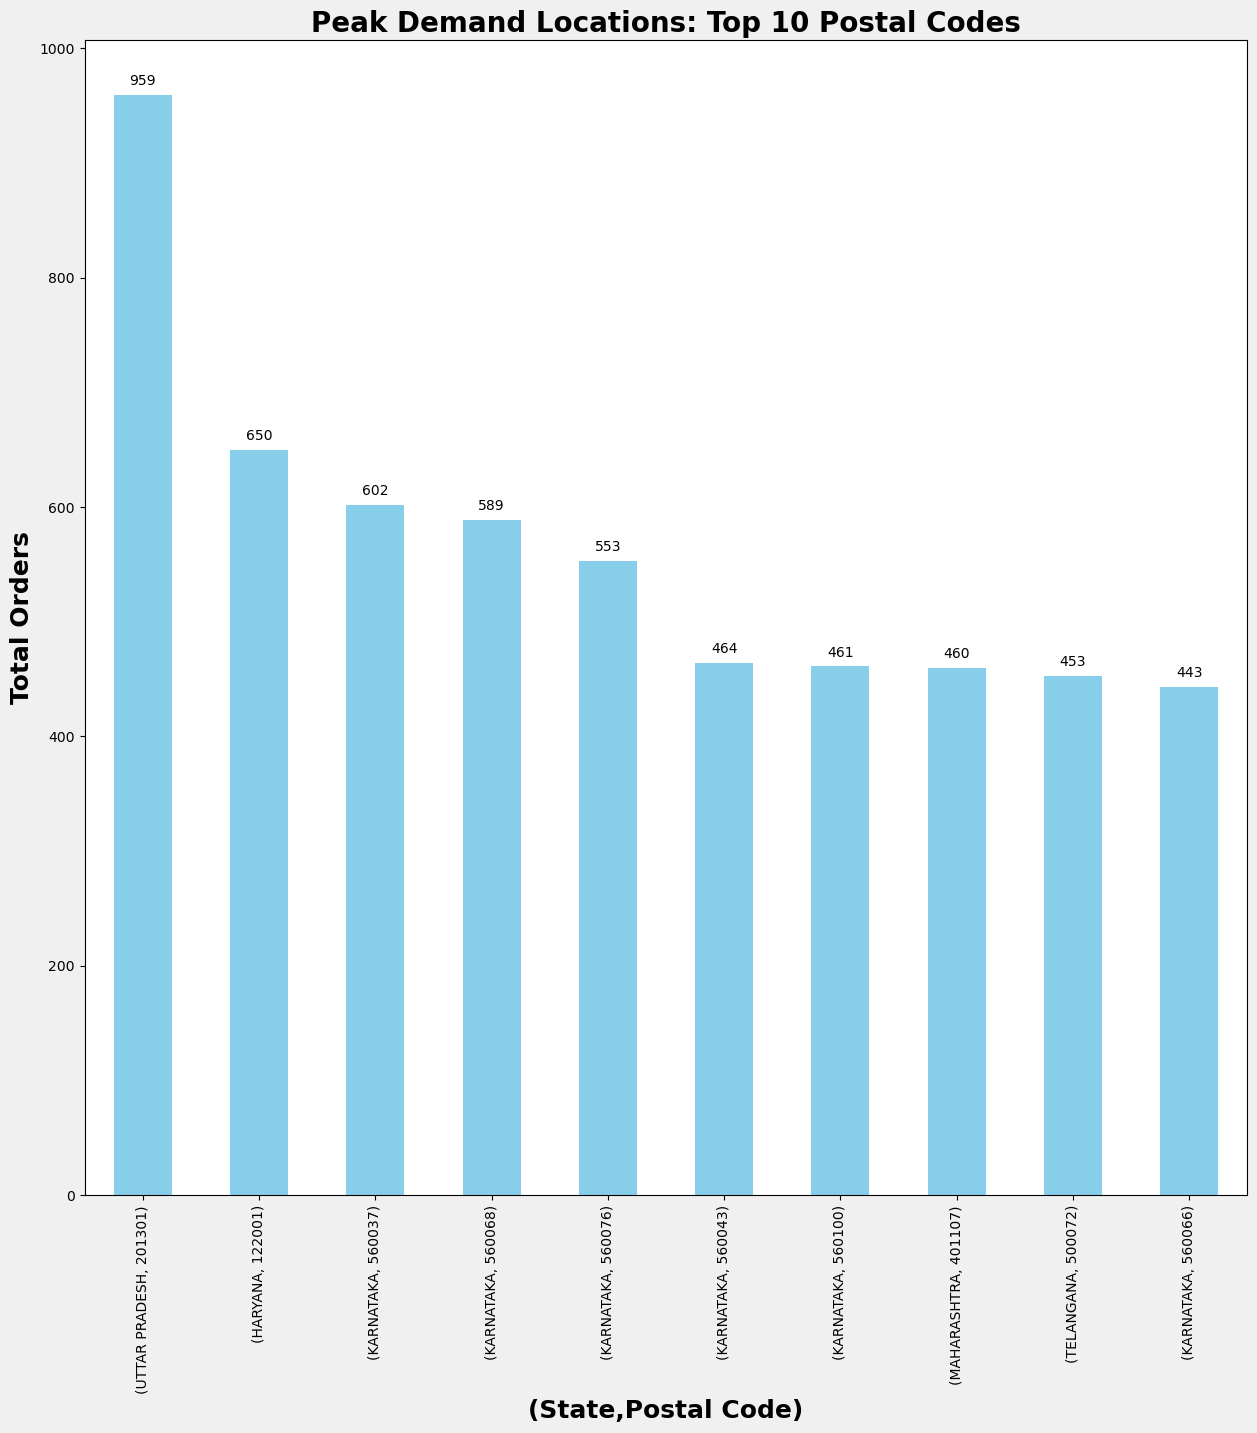

In [106]:
df_postcode_orders = df.groupby(['ship-state','ship-postal-code'])['index'].count().sort_values(ascending=False).head(10)

fig,ax = plt.subplots(figsize=(15,15),facecolor='#f0f0f0')
df_postcode_orders.plot(kind='bar',color='skyblue')
ax.set_title('Peak Demand Locations: Top 10 Postal Codes',fontsize=20,fontweight='bold')
ax.set_xlabel('(State,Postal Code)',fontsize=18,fontweight='bold')
ax.set_ylabel('Total Orders',fontsize=18,fontweight='bold')

for container in ax.containers:
    ax.bar_label(container,padding=5,fmt='%.f',label_type='edge')

##### Conclusion:-
Core Revenue Drivers: Maharashtra and Bengaluru serve as your undisputed flagship markets, anchoring Western and Southern India as the business's primary revenue generation engines.

Hyper-Local Demand Hubs: The National Capital Region (NCR)—specifically Noida (201301) and Gurugram (122001)—dominates order density, making these precise spots ideal for hyper-local distribution nodes.

Strategic Next Step: Establish micro-fulfillment hubs near Noida, Gurugram, and South/East Bengaluru (560037, 560068, 560076) to optimize last-mile delivery, compress delivery windows, and lower overall shipping costs.

### Business Recommendations:-

1. #### Core Product & Timeline Strategy:


   ##### Maximize Top Categories:

   Dedicate your primary capital to Sets and Kurtas, while using Western Dresses only during discount windows to drive quick sales spikes.

   ##### Capitalize on the Q2 Peak:

   Stock warehouses by mid-March to capture the sharp festive surge from April to mid-May, then launch a clearance event in June to combat the summer slump.
   
3. #### Regional Expansion & Marketing:

   ##### Target Regional Festivals:

   Align heavy marketing spend with early-April festivals like Gudi Padwa (Maharashtra) and Ugadi (Karnataka/Telangana) to trigger the Q2 peak.

   ##### Tier-2 Expansion:

   Deploy your high-margin premium inventory to Mumbai and Bengaluru, while expanding targeted digital ads into rising Tier-2 cities across Maharashtra and Karnataka.

   
4. #### Supply Chain & Logistics Fixes:

   ##### Eliminate Order Backlogs:

   
   While Actual cancellation rate is 8.88% which is very low but Accelerate processing speeds between order placement and shipping; 72.64% of unshipped orders are canceled by customers if delayed.

   ##### Deploy Micro-Fulfillment:

   
   Open local delivery hubs in Noida (201301), Gurugram (122001), and South/East Bengaluru to clear high order density and lower last-mile delivery costs.

   ##### Fix Shipping Channels:

   Streamline Merchant Fulfillment to clear processing bottlenecks, and audit Amazon Easy Ship to lower its high cancellation rates.

5. #### Merchandising & Promo Strategy

   ##### Protect the Core:

   Allocate 70% of production capital to Sets and Kurtas to secure your high-margin baseline revenue.

   ##### Re-evaluate the Western & Tops Strategy:

   Because Western Dresses and Tops are showing very low promotional elasticity (little to no sales lift during discounts), stop deep-discounting them. Instead, preserve your profit margins by positioning them as full-price, style-led items or shifting marketing spend away from them.

   ##### Liquidate via Bundling:

   Clear slow-moving Western wear by pairing them as lower-priced "add-ons" with fast-moving Sets

#### Exporting Datset:-

In [108]:
df.to_csv('Amazon E-commerce Sales Data Analysis.csv',index=False)

In [109]:
# For me:- Do visualizations using python and Power BI. Use MySQL as well if we want to use for for tabular outputs